# Testing with JAX framework
Better than pytorch (?)

In [1]:
import diffrax as dfx
import equinox as eqx
import jax
import jax.numpy as jnp
import optax as opx
import matplotlib.pyplot as plt 
import jax.random as jr

jax.config.update("jax_enable_x64", True) # enable 64 float precision for stiff problems

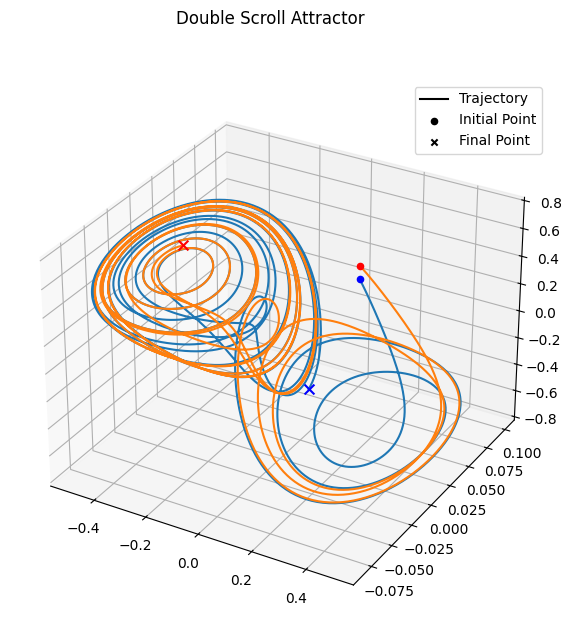

In [2]:
# generate train and val data
ALPHA, BETA, GAMMA, A, C = (10, 16, 0, 1, -0.143)

col_dict = {
    0: 'r', 
    1: 'g',
    2: 'b'
}
var_dict = {
    0: 'x',
    1: 'y',
    2: 'z'
}

def chua_model(t, xyz, args):
    alpha, beta, gamma, a, c = args 
    x,y,z = xyz 
    return jnp.array([
        alpha*(y-a*x**3-c*x),
        x-y+z, 
        -beta*y - gamma*z
    ])

T_MAX = 35

term = dfx.ODETerm(chua_model)
solver = dfx.Dopri5()
y0 = jnp.array((0.0001, 0.1, 0))
y0_alt = jnp.array((0.0001, 0.1, 0.1))
saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX, 0.01))

sol = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat)
sol_alt = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0_alt, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat)

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(projection='3d'), )

ax.plot(sol.ys[:, 0],sol.ys[:, 1],sol.ys[:, 2], color='C0', alpha=1)
ax.scatter(sol.ys[0:1, 0],sol.ys[0:1, 1],sol.ys[0:1, 2], color='blue', marker='o')
ax.scatter(sol_alt.ys[0:1, 0],sol_alt.ys[0:1, 1],sol_alt.ys[0:1, 2], color='red', marker='o')


ax.scatter(sol.ys[-1:, 0],sol.ys[-1:, 1],sol.ys[-1:, 2], color='blue', marker='x', s=50)
ax.scatter(sol_alt.ys[-1:, 0],sol_alt.ys[-1:, 1],sol_alt.ys[-1:, 2], color='red', marker='x', s=50)

ax.plot(sol_alt.ys[:, 0],sol_alt.ys[:, 1],sol_alt.ys[:, 2], color='C1', alpha=1)

ax.plot([], [], label="Trajectory", color='k')
ax.scatter([], [], marker='o', label="Initial Point", color='k')
ax.scatter([], [], marker='x', label="Final Point", color='k')

ax.legend()

plt.suptitle("Double Scroll Attractor")

plt.show()

In [6]:
T_MAX = 10
@jax.jit
def get_training_set(ALPHA, BETA, GAMMA, A, C):
    term = dfx.ODETerm(chua_model)
    solver = dfx.Dopri5()
    y0 = jnp.array((0.0001, 0.1, 0))
    saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX, 0.1))

    # training set
    sol_train = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat)

    x_train = sol_train.ys[::1]
    t_train = sol_train.ts[::1]

    # validation set
    saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX+T_MAX*0.5, 0.15))
    y0 = jnp.array((0.0001, 0.1, 0.1))
    sol_val = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX+T_MAX*0.5, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat)

    x_val = sol_val.ys[::1]
    t_val = sol_val.ts[::1]

    return x_train, t_train, x_val, t_val, sol_train, sol_val

In [7]:
x_train, t_train, x_val, t_val, sol_train, sol_val = get_training_set(ALPHA, BETA, GAMMA, A, C)


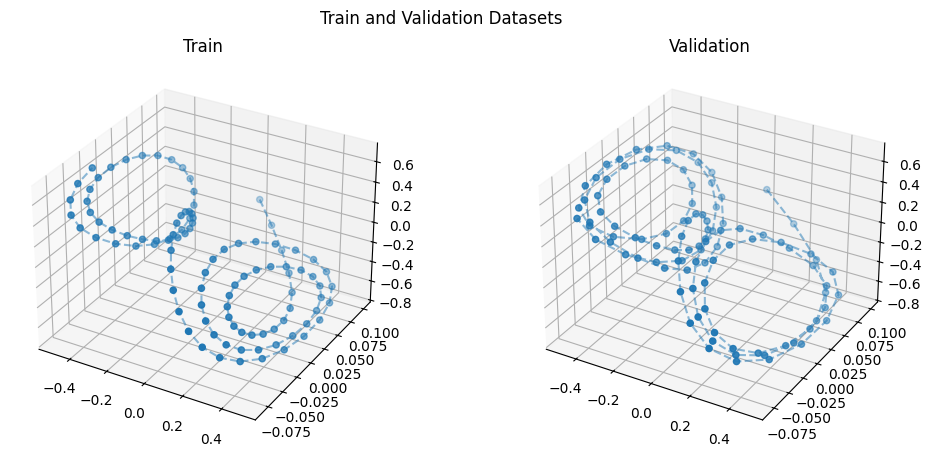

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw=dict(projection='3d'))

axes[0].scatter(x_train[:, 0],x_train[:, 1],x_train[:, 2])
axes[1].scatter(x_val[:, 0],x_val[:, 1],x_val[:, 2])

axes[0].plot(sol_train.ys[:, 0],sol_train.ys[:, 1],sol_train.ys[:, 2], alpha=0.5, linestyle='--')
axes[1].plot(sol_val.ys[:, 0],sol_val.ys[:, 1],sol_val.ys[:, 2], alpha=0.5, linestyle='--')

axes[0].set_title("Train")
axes[1].set_title("Validation")

plt.suptitle("Train and Validation Datasets")

plt.show()

In [9]:
t_train.shape

(100,)

In [10]:
t_val.shape

(100,)

In [11]:
def zero_last_layer(mlp):
    last = mlp.layers[-1]

    new_last = eqx.tree_at(
        lambda l: (l.weight, l.bias),
        last,
        (
            jnp.zeros_like(last.weight),
            jnp.zeros_like(last.bias),
        ),
    )

    mlp = eqx.tree_at(lambda m: m.layers[-1], mlp, new_last)
    return mlp

In [12]:
class LinearInterpolator(eqx.Module):
    t_obs: jax.Array
    y_obs: jax.Array

    def __call__(self, t):
        t = jnp.clip(t, self.t_obs[0], self.t_obs[-1])
        idx = jnp.searchsorted(self.t_obs, t, side="left")
        idx = jnp.clip(idx, 1, self.t_obs.shape[0] - 1)

        t0, t1 = self.t_obs[idx - 1], self.t_obs[idx]
        y0, y1 = self.y_obs[idx - 1], self.y_obs[idx]
        w = (t - t0) / (t1 - t0 + 1e-12)
        return (1.0 - w) * y0 + w * y1

In [13]:
class ChuaUdeX_PEM(eqx.Module):
    net: eqx.nn.MLP
    alpha: float
    beta: float 
    gamma: float 
    K: jax.Array

    def __init__(self, alpha, beta, gamma, K, key):
        self.net = eqx.nn.MLP(
            in_size='scalar',
            out_size='scalar',
            width_size=64,
            depth=3,
            activation=jax.nn.leaky_relu,
            key=key,
        )
        
        self.alpha = alpha 
        self.beta = beta 
        self.gamma = gamma 
        self.K = jnp.asarray(K)

        # zero weight the layer
        self.net = zero_last_layer(self.net)


    def physics(self, t, state):
        # known terms
        x, y, z = state
        return jnp.array(
            [self.alpha*y, x-y+z, -self.beta*y-self.gamma*z]
        )

    def residual(self, t, state):
        x, _, _ = state
        return jnp.array(
            [-self.alpha*self.net(x), 0,0]
        )
    
    def error(self, t, state, obs_fun):
        y_hat = obs_fun(t)
        return y_hat - state

    def __call__(self, t, state, args):
        obs_fun = args
        return self.physics(t, state) + self.residual(t, state) + self.K * self.error(t, state, obs_fun)


In [14]:
class NDEBaseline(eqx.Module):
    net : eqx.nn.MLP

    def __init__(self, key):
        self.net = eqx.nn.MLP(
            in_size=3,
            out_size=3,
            width_size=128,
            depth=5,
            activation=jax.nn.relu, 
            key=key 
        )

    def __call__(self, t, y, args):
        return self.net(y)

In [15]:
class ChuaUdeX(eqx.Module):
    net: eqx.nn.MLP
    alpha: float
    beta: float 
    gamma: float 

    def __init__(self, alpha, beta, gamma, key):
        self.net = eqx.nn.MLP(
            in_size='scalar',
            out_size='scalar',
            width_size=128,
            depth=5,
            activation=jax.nn.relu,
            key=key,
        )
        
        self.alpha = alpha 
        self.beta = beta 
        self.gamma = gamma 

        # zero weight the layer
        self.net = zero_last_layer(self.net)


    def physics(self, t, state):
        # known terms
        x, y, z = state
        return jnp.array(
            [self.alpha*y, x-y+z, -self.beta*y-self.gamma*z]
        )

    def residual(self, t, state):
        x, _, _ = state
        return jnp.array(
            [-self.alpha*self.net(x), 0,0]
        )
    

    def __call__(self, t, state, args):
        return self.physics(t, state) + self.residual(t, state)


In [16]:
def solve_ude(model, y0, ts):
    term = dfx.ODETerm(model)
    solver = dfx.Kvaerno3()
    saveat = dfx.SaveAt(ts=ts)
    stepper = dfx.PIDController(rtol=1e-7, atol=1e-9)

    sol = dfx.diffeqsolve(
        term,
        solver,
        t0=ts[0],
        t1=ts[-1],
        dt0=ts[1] - ts[0],
        y0=y0,
        saveat=saveat,
        stepsize_controller=stepper
    )
    return sol.ys



In [17]:
def solve_ude_light(model, y0, ts):
    term = dfx.ODETerm(model)
    solver = dfx.Tsit5()
    saveat = dfx.SaveAt(ts=ts)
    stepper = dfx.PIDController(rtol=1e-6, atol=1e-8)

    sol = dfx.diffeqsolve(
        term,
        solver,
        t0=ts[0],
        t1=ts[-1],
        dt0=ts[1] - ts[0],
        y0=y0,
        saveat=saveat,
        stepsize_controller=stepper
    )
    return sol.ys



In [21]:
key = jr.PRNGKey(0)
nde = NDEBaseline(key)

# Train baseline NDE
lr = 0.01
n_epochs = 500
optimizer = opx.adam(lr)
opt_state = optimizer.init(eqx.filter(nde, eqx.is_inexact_array))

@eqx.filter_value_and_grad
def loss_fn(model, x0, y_true, ts):
    # calculate loss
    pred = solve_ude_light(model, x0, ts)
    return jnp.mean((pred - y_true) ** 2)

@eqx.filter_jit
def train_step(model, opt_state, x0, x_true, ts, optimizer):
    # one train step on the dataset
    loss, grads = loss_fn(model, x0, x_true, ts)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

baseline_train_losses = []
baseline_val_losses = []

for i in range(0, n_epochs):
    nde, opt_state, loss = train_step(nde, opt_state, x_train[0], x_train, t_train, optimizer)

    val_loss = loss_fn(nde, x_val[0], x_val, t_val)[0]
 
    print(f"{i}\t{loss:.4e}\t{val_loss:.4e}")

    baseline_train_losses.append(loss)
    baseline_val_losses.append(val_loss)

0	1.8683e-01	2.4860e+00
1	8.9033e-01	1.1089e-01
2	9.5315e-02	7.4569e-02
3	8.1799e-02	8.8471e-02
4	8.6324e-02	8.5222e-02
5	8.3053e-02	7.8068e-02
6	7.9033e-02	7.5691e-02
7	7.9314e-02	7.4880e-02
8	8.0542e-02	8.0635e-02
9	7.9874e-02	7.5435e-02
10	7.8903e-02	7.5460e-02
11	7.9745e-02	7.4050e-02
12	7.8069e-02	7.9561e-02
13	7.9341e-02	7.3150e-02
14	7.8214e-02	7.1177e-02
15	7.8706e-02	7.1659e-02
16	7.8464e-02	7.4278e-02
17	7.7951e-02	7.8563e-02
18	7.8651e-02	7.4931e-02
19	7.8006e-02	7.2145e-02
20	7.8120e-02	7.1404e-02
21	7.8276e-02	7.1607e-02
22	7.7954e-02	7.4180e-02
23	7.8121e-02	7.4607e-02
24	7.7993e-02	7.3228e-02
25	7.7799e-02	7.3105e-02
26	7.8026e-02	7.3121e-02
27	7.7831e-02	7.3939e-02
28	7.7741e-02	7.4430e-02
29	7.7819e-02	7.2657e-02
30	7.7599e-02	7.2026e-02
31	7.7674e-02	7.2976e-02
32	7.7513e-02	7.4067e-02
33	7.7410e-02	7.3631e-02
34	7.7345e-02	7.2530e-02
35	7.7153e-02	7.2830e-02
36	7.6950e-02	7.3754e-02
37	7.6795e-02	7.1512e-02
38	7.6392e-02	7.2536e-02
39	7.5919e-02	7.3702e-02
40	7.5247e

In [22]:
key = jr.PRNGKey(0)
ude = ChuaUdeX(ALPHA, BETA, GAMMA, key)

# Train Normal UDE
lr = 0.01
n_epochs = 500
optimizer = opx.adam(lr)
opt_state = optimizer.init(eqx.filter(ude, eqx.is_inexact_array))

@eqx.filter_value_and_grad
def loss_fn(model, x0, y_true, ts):
    # calculate loss
    pred = solve_ude_light(model, x0, ts)
    return jnp.mean((pred - y_true) ** 2)

@eqx.filter_jit
def train_step(model, opt_state, x0, x_true, ts, optimizer):
    # one train step on the dataset
    loss, grads = loss_fn(model, x0, x_true, ts)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

train_losses = []
val_losses = []

for i in range(0, n_epochs):
    ude, opt_state, loss = train_step(ude, opt_state, x_train[0], x_train, t_train, optimizer)

    val_loss = loss_fn(ude, x_val[0], x_val, t_val)[0]

    print(f"{i}\t{loss:.4e}\t{val_loss:.4e}")

    train_losses.append(loss)
    val_losses.append(val_loss)

0	8.0243e-02	8.2349e+01
1	2.7679e+01	4.2193e-02
2	7.9763e-02	1.3737e+03
3	8.1589e+01	1.6833e-01
4	9.7852e-02	2.8404e+00
5	1.0024e+00	2.0597e+00
6	1.1038e+00	7.4992e-01
7	7.0350e-01	1.7762e-01
8	2.5068e-01	5.4166e-02
9	9.0069e-02	9.0676e+06
10	3.0395e+03	1.4336e-01
11	2.2332e-01	7.2781e-01
12	8.3314e-01	5.2291e+00
13	4.1510e+00	4.0906e+01
14	1.8467e+01	6.0045e+01
15	2.4951e+01	1.1160e+01
16	8.2388e+00	2.3622e+00
17	2.3861e+00	8.9840e-01
18	1.0568e+00	4.5552e-01
19	5.9116e-01	2.6915e-01
20	3.6310e-01	1.3508e-01
21	1.9012e-01	1.0762e-01
22	1.0584e-01	5.7726e-01
23	3.2511e-01	1.2347e-01
24	1.1637e-01	1.4489e-01
25	1.3467e-01	1.8869e-01
26	1.6598e-01	2.2777e-01
27	1.9209e-01	2.5431e-01
28	2.0757e-01	2.6694e-01
29	2.1238e-01	2.6647e-01
30	2.0857e-01	2.5586e-01
31	1.9910e-01	2.4323e-01
32	1.8941e-01	2.2942e-01
33	1.7854e-01	2.1024e-01
34	1.6586e-01	1.8625e-01
35	1.5279e-01	1.5501e-01
36	1.3581e-01	1.1709e-01
37	1.1087e-01	8.7187e-02
38	8.9507e-02	8.2336e-02
39	9.1786e-02	3.8675e+08
40	1.2997e

In [39]:
def solve_ude_light_pem(model, y0, ts, obs_fun):
    term = dfx.ODETerm(model)
    solver = dfx.Tsit5()
    saveat = dfx.SaveAt(ts=ts)
    stepper = dfx.PIDController(rtol=1e-7, atol=1e-8)

    sol = dfx.diffeqsolve(
        term,
        solver,
        t0=ts[0],
        t1=ts[-1],
        dt0=ts[1] - ts[0],
        y0=y0,
        saveat=saveat,
        stepsize_controller=stepper,
        args=obs_fun
    )
    return sol.ys


@eqx.filter_value_and_grad
def loss_fn_pem(model, x0, y_true, ts, obs_fun):
    # calculate loss
    pred = solve_ude_light_pem(model, x0, ts, obs_fun)
    return jnp.mean((pred - y_true) ** 2)

@eqx.filter_jit
def train_step_pem(model, opt_state, x0, x_true, ts, optimizer, obs_fun):
    # one train step on the dataset
    loss, grads = loss_fn_pem(model, x0, x_true, ts, obs_fun)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss


In [40]:
key = jr.PRNGKey(0)
linear_interp = LinearInterpolator(t_train, x_train)
linear_interp_jit = eqx.filter_jit(linear_interp)

linear_interp_val = LinearInterpolator(t_val, x_val)
linear_interp_jit_val = eqx.filter_jit(linear_interp_val)

ude_pem = ChuaUdeX_PEM(ALPHA, BETA, GAMMA, [0.3, 0.1, 0.1], key)

# Train UDE PEM 

lr = 0.01
n_epochs = 500
optimizer = opx.adam(lr)
opt_state = optimizer.init(eqx.filter(ude_pem, eqx.is_inexact_array))

train_losses_pem = []
val_losses_pem = []

for i in range(0, n_epochs):
    ude_pem, opt_state, loss = train_step_pem(ude_pem, opt_state, x_train[0], x_train, t_train, optimizer, linear_interp_jit)

    val_loss = loss_fn_pem(ude_pem, x_val[0], x_val, t_val, linear_interp_jit_val)[0]

    print(f"{i}\t{loss:.4e}\t{val_loss:.4e}")

    train_losses_pem.append(loss)
    val_losses_pem.append(val_loss)

0	4.7346e-02	8.8316e+00
1	5.5303e+00	4.4220e-02
2	5.7434e-02	1.0671e-01
3	1.1338e-01	7.9178e-02
4	8.0259e-02	4.7088e-02
5	6.8700e-02	6.2432e-02
6	8.9097e-02	4.5578e-02
7	5.5948e-02	7.8056e-02
8	7.5253e-02	6.9450e-02
9	6.9287e-02	3.6879e-02
10	4.9098e-02	5.7435e-02
11	7.9223e-02	4.1369e-02
12	4.9353e-02	7.1411e-02
13	6.9081e-02	6.9092e-02
14	6.7150e-02	4.2086e-02
15	4.8337e-02	4.7211e-02
16	6.6652e-02	3.4398e-02
17	4.5219e-02	4.4341e-02
18	4.9224e-02	4.7107e-02
19	5.1924e-02	3.5856e-02
20	4.2165e-02	3.9514e-02
21	4.0468e-02	9.1124e-02
22	6.1950e-02	1.2409e-01
23	1.0476e-01	1.6593e-01
24	1.5188e-01	1.8538e-01
25	1.4353e-01	2.3197e-01
26	1.1382e-01	2.3126e-01
27	1.0242e-01	1.7163e-01
28	1.0440e-01	1.4079e-01
29	1.0671e-01	1.2861e-01
30	1.0835e-01	1.2685e-01
31	1.0771e-01	1.3669e-01
32	1.0149e-01	1.4721e-01
33	8.8079e-02	1.3163e-01
34	7.3199e-02	1.0390e-01
35	6.8812e-02	9.1029e-02
36	7.4528e-02	8.8995e-02
37	7.6586e-02	8.3366e-02
38	7.0173e-02	7.4740e-02
39	6.1180e-02	6.7509e-02
40	5.5946e

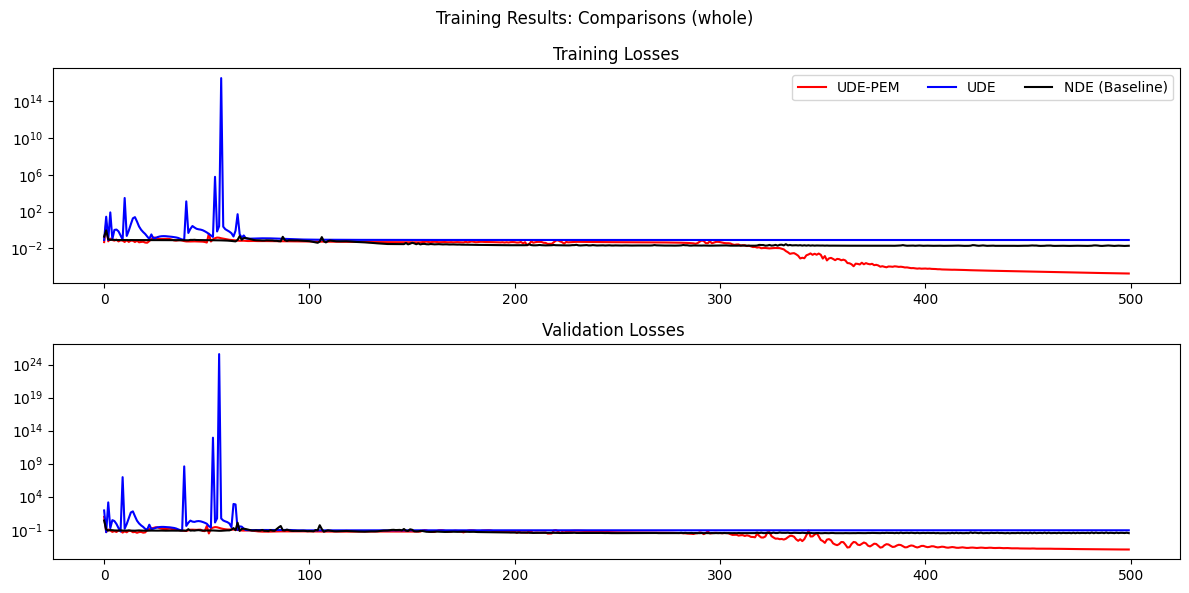

In [53]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

N = 365

plt.sca(axes[1])
plt.title("Validation Losses ")

plt.semilogy(range(0, 500), val_losses_pem, color='r')
plt.semilogy(val_losses, color='b')
plt.semilogy(baseline_val_losses, color='k')

plt.sca(axes[0])

plt.title("Training Losses")
plt.semilogy(train_losses_pem, color='r')
plt.semilogy(train_losses, color='b')
plt.semilogy(baseline_train_losses, color='k')


plt.plot([], [], color='r', label="UDE-PEM")
plt.plot([], [], color='b', label="UDE")
plt.plot([], [], color='k', label="NDE (Baseline)")

plt.legend(ncol=4)

plt.suptitle("Training Results: Comparisons (whole)")
plt.tight_layout()
plt.show()


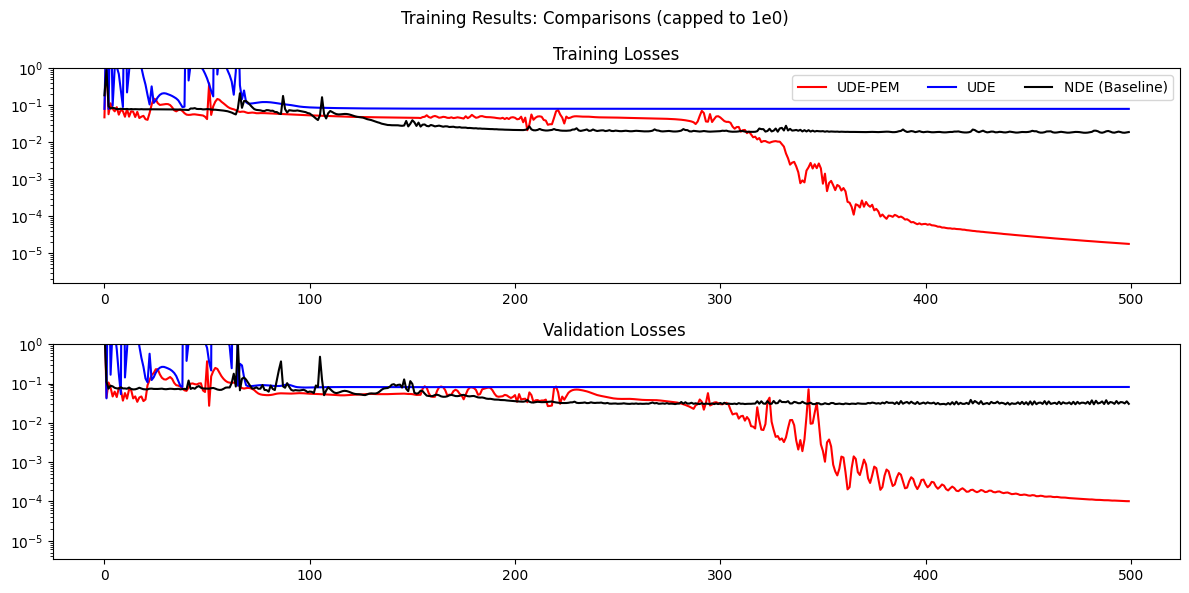

In [52]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

N = 365

plt.sca(axes[1])
plt.title("Validation Losses ")

plt.semilogy(range(0, 500), val_losses_pem, color='r')
plt.semilogy(val_losses, color='b')
plt.semilogy(baseline_val_losses, color='k')
plt.ylim(None, 1e0)

plt.sca(axes[0])

plt.title("Training Losses")
plt.semilogy(train_losses_pem, color='r')
plt.semilogy(train_losses, color='b')
plt.semilogy(baseline_train_losses, color='k')
plt.ylim(None, 1e0, )


plt.plot([], [], color='r', label="UDE-PEM")
plt.plot([], [], color='b', label="UDE")
plt.plot([], [], color='k', label="NDE (Baseline)")

plt.legend(ncol=4)

plt.suptitle("Training Results: Comparisons (capped to 1e0)")
plt.tight_layout()
plt.show()


In [43]:
# save model
eqx.tree_serialise_leaves("./models_weights/31_3_ude_jax.eqx", ude)
eqx.tree_serialise_leaves("./models_weights/31_3_ude_pem_jax.eqx", ude_pem)


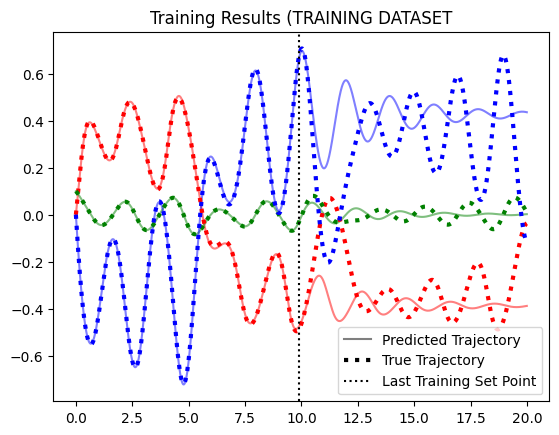

In [56]:
term = dfx.ODETerm(chua_model)
term_ude = dfx.ODETerm(ude_pem)

T_MAX = 20

solver = dfx.Tsit5()
y0 = x_train[0]
t_eval = jnp.arange(0, T_MAX, 0.01)
saveat = dfx.SaveAt(ts=t_eval)
stepper = dfx.PIDController(rtol=1e-7, atol=1e-9)

# training set
sol = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat, stepsize_controller=stepper)
traj_true = sol.ys

traj_final = dfx.diffeqsolve(term_ude, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0, args=(linear_interp_jit), saveat=saveat, stepsize_controller=stepper).ys

plt.plot(t_eval, traj_final[:, 0], color='r', alpha=0.5)
plt.plot(t_eval, traj_final[:, 1], color='g', alpha=0.5)
plt.plot(t_eval, traj_final[:, 2], color='b', alpha=0.5)

plt.plot(t_eval, traj_true[:, 0], color='r', linestyle=':',  linewidth=3)
plt.plot(t_eval, traj_true[:, 1], color='g', linestyle=':',  linewidth=3)
plt.plot(t_eval, traj_true[:, 2], color='b', linestyle=':',  linewidth=3)

plt.plot([], [], color="k", alpha=0.5, label="Predicted Trajectory")
plt.plot([], [], color="k", linestyle=':',  linewidth=3, label="True Trajectory")
plt.axvline(t_train[-1], color="k", linestyle=":", label="Last Training Set Point")

plt.legend()
plt.title("Training Results (TRAINING DATASET")
plt.show()

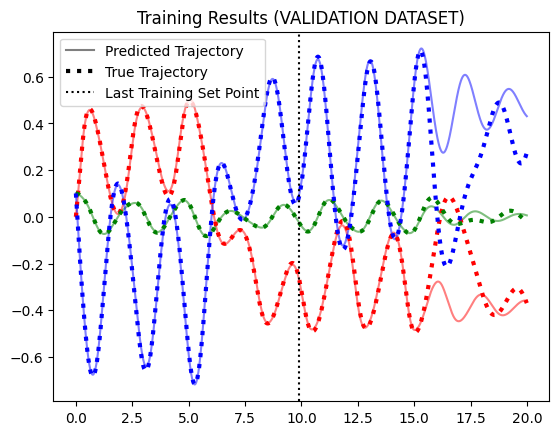

In [57]:
term = dfx.ODETerm(chua_model)
term_ude = dfx.ODETerm(ude_pem)

T_MAX = 20

solver = dfx.Tsit5()
y0 = x_train[0]
t_eval = jnp.arange(0, T_MAX, 0.01)
saveat = dfx.SaveAt(ts=t_eval)
stepper = dfx.PIDController(rtol=1e-7, atol=1e-9)

# training set
sol = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0_alt, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat, stepsize_controller=stepper)
traj_true = sol.ys

traj_final = dfx.diffeqsolve(term_ude, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0_alt, args=(linear_interp_jit_val), saveat=saveat, stepsize_controller=stepper).ys

plt.plot(t_eval, traj_final[:, 0], color='r', alpha=0.5)
plt.plot(t_eval, traj_final[:, 1], color='g', alpha=0.5)
plt.plot(t_eval, traj_final[:, 2], color='b', alpha=0.5)

plt.plot(t_eval, traj_true[:, 0], color='r', linestyle=':',  linewidth=3)
plt.plot(t_eval, traj_true[:, 1], color='g', linestyle=':',  linewidth=3)
plt.plot(t_eval, traj_true[:, 2], color='b', linestyle=':',  linewidth=3)

plt.plot([], [], color="k", alpha=0.5, label="Predicted Trajectory")
plt.plot([], [], color="k", linestyle=':',  linewidth=3, label="True Trajectory")
plt.axvline(t_train[-1], color="k", linestyle=":", label="Last Training Set Point")

plt.legend()
plt.title("Training Results (VALIDATION DATASET)")
plt.show()

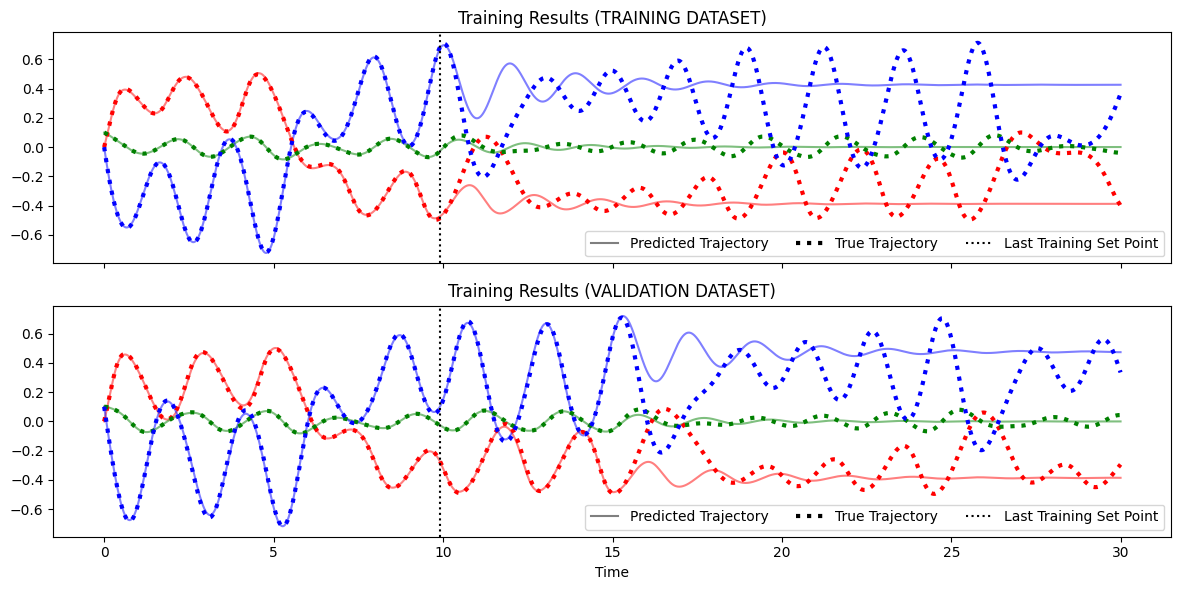

In [67]:
term = dfx.ODETerm(chua_model)
term_ude = dfx.ODETerm(ude_pem)

T_MAX = 30

solver = dfx.Tsit5()
t_eval = jnp.arange(0, T_MAX, 0.01)
saveat = dfx.SaveAt(ts=t_eval)
stepper = dfx.PIDController(rtol=1e-7, atol=1e-9)

# Create figure with 2 rows and 1 column
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=True)

datasets = [
    {
        "y0": x_train[0],
        "interp": linear_interp_jit,
        "title": "Training Results (TRAINING DATASET)"
    },
    {
        "y0": y0_alt,
        "interp": linear_interp_jit_val,
        "title": "Training Results (VALIDATION DATASET)"
    }
]

for ax, ds in zip(axes, datasets):

    # True trajectory
    sol = dfx.diffeqsolve(
        term,
        solver,
        t0=0,
        t1=T_MAX,
        dt0=0.1,
        y0=ds["y0"],
        args=(ALPHA, BETA, GAMMA, A, C),
        saveat=saveat,
        stepsize_controller=stepper
    )
    traj_true = sol.ys

    # Predicted trajectory
    traj_final = dfx.diffeqsolve(
        term_ude,
        solver,
        t0=0,
        t1=T_MAX,
        dt0=0.1,
        y0=ds["y0"],
        args=(ds["interp"]),
        saveat=saveat,
        stepsize_controller=stepper
    ).ys

    # Predicted
    ax.plot(t_eval, traj_final[:, 0], color='r', alpha=0.5)
    ax.plot(t_eval, traj_final[:, 1], color='g', alpha=0.5)
    ax.plot(t_eval, traj_final[:, 2], color='b', alpha=0.5)

    # Ground truth
    ax.plot(t_eval, traj_true[:, 0], color='r', linestyle=':', linewidth=3)
    ax.plot(t_eval, traj_true[:, 1], color='g', linestyle=':', linewidth=3)
    ax.plot(t_eval, traj_true[:, 2], color='b', linestyle=':', linewidth=3)

    # Legend helpers
    ax.plot([], [], color="k", alpha=0.5, label="Predicted Trajectory")
    ax.plot([], [], color="k", linestyle=':', linewidth=3, label="True Trajectory")

    # Training boundary
    ax.axvline(t_train[-1], color="k", linestyle=":", label="Last Training Set Point")

    ax.set_title(ds["title"])
    ax.legend(ncol=3)

axes[-1].set_xlabel("Time")

plt.tight_layout()
plt.show()

altra figura: provo a veder ele MLE